In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from pathlib import Path
from Models.Fuzzy_CNN_LSTM import FuzzyConvLSTM

In [2]:
project_root = Path.cwd().parent  # Go up one level from /notebooks/ to the project root
data_path = project_root / "Data" / "Processed Data" / "AirQualityUCI_cleaned.csv"

# --- Load the Dataset ---
df = pd.read_csv(data_path)

# Features 
X = df[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 
        'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]

# Target 
y = df['C6H6(GT)']  # benzene concentration

# --- Preview the Data ---
df.head()

,Date,Time,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,1360.00,11.881723,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,1292.25,9.397165,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,1402.00,8.997817,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,1375.50,9.228796,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1272.25,6.518224,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794


In [3]:
SEED = 42
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=SEED)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=SEED)

In [4]:
scaler_X = StandardScaler()
x_train = scaler_X.fit_transform(x_train)
x_val   = scaler_X.transform(x_val)
x_test  = scaler_X.transform(x_test)

In [5]:
y_train = y_train.to_numpy().reshape(-1, 1)
y_val   = y_val.to_numpy().reshape(-1, 1)
y_test  = y_test.to_numpy().reshape(-1, 1)

In [6]:
SEQ_LEN = 10

def create_sequences(X, y, seq_len):
    xs, ys = [], []
    for i in range(len(X) - seq_len):
        xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])  # predict next step
    return np.array(xs), np.array(ys)

x_train_seq, y_train_seq = create_sequences(x_train, y_train, SEQ_LEN)
x_val_seq, y_val_seq     = create_sequences(x_val, y_val, SEQ_LEN)
x_test_seq, y_test_seq   = create_sequences(x_test, y_test, SEQ_LEN)

In [7]:
x_train_seq = torch.tensor(x_train_seq, dtype=torch.float32)
y_train_seq = torch.tensor(y_train_seq, dtype=torch.float32)
x_val_seq   = torch.tensor(x_val_seq, dtype=torch.float32)
y_val_seq   = torch.tensor(y_val_seq, dtype=torch.float32)
x_test_seq  = torch.tensor(x_test_seq, dtype=torch.float32)
y_test_seq  = torch.tensor(y_test_seq, dtype=torch.float32)

In [8]:
BATCH_SIZE = 32

train_loader = DataLoader(TensorDataset(x_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_seq, y_val_seq), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(x_test_seq, y_test_seq), batch_size=BATCH_SIZE, shuffle=False)

In [9]:
# ---------------------------
# 1. Fuzzy Input Layer
# ---------------------------
class FuzzyInputLayer(nn.Module):
    def __init__(self, input_dim, num_mfs):
        """
        input_dim: number of input features
        num_mfs: number of fuzzy membership functions per feature
        """
        super().__init__()
        self.input_dim = input_dim
        self.num_mfs = num_mfs

        # Learnable Gaussian parameters
        self.centers = nn.Parameter(torch.randn(input_dim, num_mfs))
        self.sigmas = nn.Parameter(torch.ones(input_dim, num_mfs))

    def forward(self, x):
        """
        x: [batch_size, input_dim, seq_len]
        returns: [batch_size, input_dim * num_mfs, seq_len]
        """
        batch_size, input_dim, seq_len = x.shape
        x_expanded = x.unsqueeze(2)  # [batch, input_dim, 1, seq_len]
        c = self.centers.unsqueeze(0).unsqueeze(-1)  # [1, input_dim, num_mfs, 1]
        s = self.sigmas.unsqueeze(0).unsqueeze(-1)

        mu = torch.exp(-0.5 * ((x_expanded - c) / (s + 1e-6)) ** 2)
        mu = mu.view(batch_size, input_dim * self.num_mfs, seq_len)
        return mu

# ---------------------------
# 2. Full Model
# ---------------------------
class FuzzyConvLSTM(nn.Module):
    def __init__(self, input_dim, num_mfs, conv_channels, lstm_hidden, output_dim,
                 kernel_size=3, pool_size=2, dropout=0.3):
        super().__init__()

        self.fuzzy = FuzzyInputLayer(input_dim, num_mfs)
        fuzzy_out_channels = input_dim * num_mfs

        self.conv1 = nn.Conv1d(in_channels=fuzzy_out_channels,
                               out_channels=conv_channels,
                               kernel_size=kernel_size,
                               padding=kernel_size // 2)
        self.pool = nn.MaxPool1d(pool_size)
        self.lstm = nn.LSTM(input_size=conv_channels,
                            hidden_size=lstm_hidden,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        x: [batch_size, input_dim, seq_len]
        """
        # Fuzzification
        x = self.fuzzy(x)

        # Conv + Pool
        x = F.relu(self.conv1(x))
        x = self.pool(x)  # [batch, conv_channels, reduced_seq_len]

        # Prepare for LSTM: [batch, seq_len, features]
        x = x.permute(0, 2, 1)

        # LSTM
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]  # last hidden state

        # Dropout + FC + ReLU
        x = self.dropout(x)
        x = self.fc(x)
        x = self.relu(x)

        return x

In [10]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Instantiate model
model = FuzzyConvLSTM(
    input_dim= SEQ_LEN,  # number of features
    num_mfs=5,                       # number of fuzzy sets per feature
    conv_channels=32,
    lstm_hidden=128,
    output_dim= 1                     
).to(device)

# Define loss and optimizer
criterion = nn.MSELoss()  # use nn.CrossEntropyLoss() if classification
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Using device: cpu


In [11]:
EPOCHS = 200

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)

        # Make sure shapes match
        preds = preds.squeeze()
        yb = yb.squeeze()

        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)  # Save train loss

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            preds = preds.squeeze()
            yb = yb.squeeze()
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)  # Save validation loss

    if epoch % 10 == 9:
        print(f'Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f} | validation_loss: {val_loss:.4f}')


Epoch 10/200: train_loss: 2.6130 | validation_loss: 2.0756
Epoch 20/200: train_loss: 1.1647 | validation_loss: 0.8858
Epoch 30/200: train_loss: 0.9018 | validation_loss: 0.4575
Epoch 40/200: train_loss: 0.8252 | validation_loss: 0.3456
Epoch 50/200: train_loss: 0.7228 | validation_loss: 0.1666
Epoch 60/200: train_loss: 0.6714 | validation_loss: 0.1953
Epoch 70/200: train_loss: 0.6367 | validation_loss: 0.1800
Epoch 80/200: train_loss: 0.6278 | validation_loss: 0.1907
Epoch 90/200: train_loss: 0.5781 | validation_loss: 0.3933
Epoch 100/200: train_loss: 0.5569 | validation_loss: 0.3264
Epoch 110/200: train_loss: 0.5268 | validation_loss: 0.1965
Epoch 120/200: train_loss: 0.5836 | validation_loss: 0.1908
Epoch 130/200: train_loss: 0.4948 | validation_loss: 0.4541
Epoch 140/200: train_loss: 0.4829 | validation_loss: 0.2092
Epoch 150/200: train_loss: 0.4706 | validation_loss: 0.2600
Epoch 160/200: train_loss: 0.4377 | validation_loss: 0.3556
Epoch 170/200: train_loss: 0.4305 | validation_lo

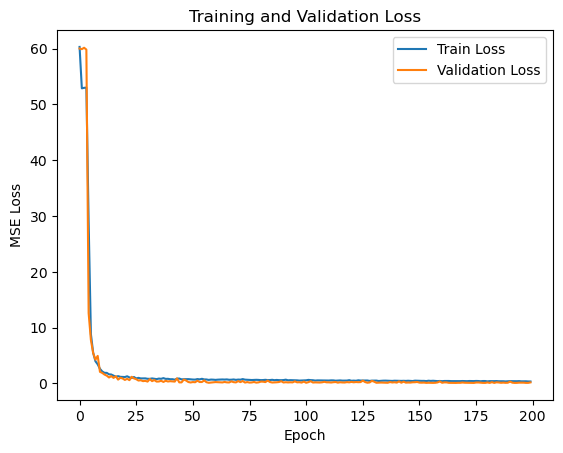

In [12]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

Test RMSE: 0.4149


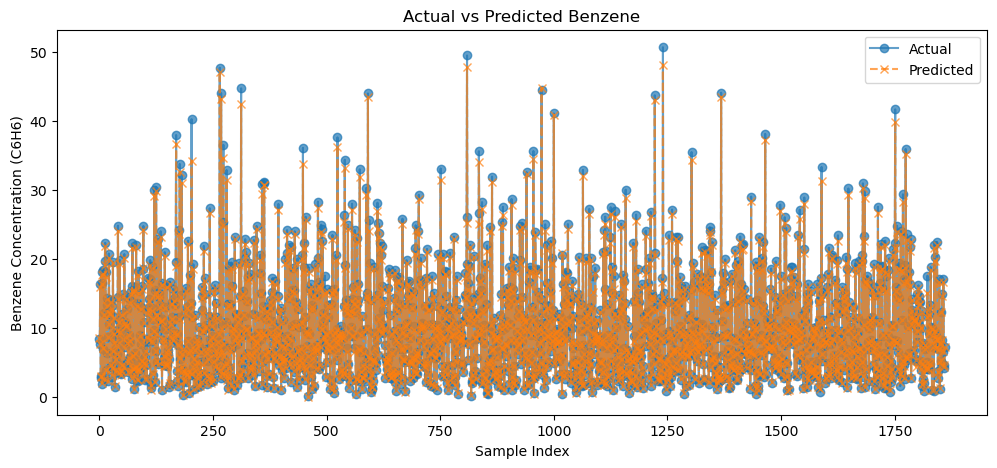

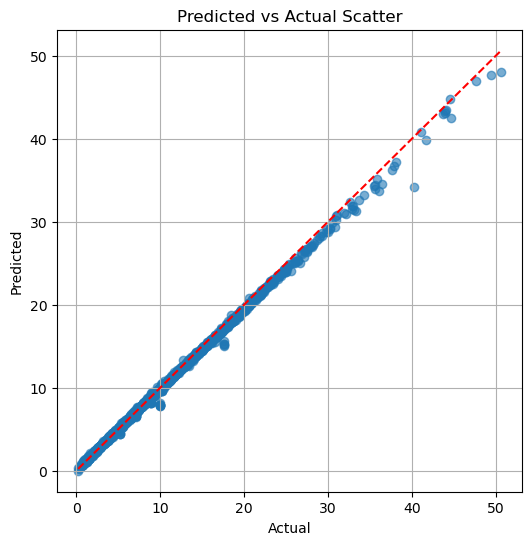

In [13]:
model.eval()
y_preds, y_trues = [], []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        pred = model(x_batch)
        y_preds.append(pred)
        y_trues.append(y_batch)

# Concatenate all batches
y_pred_tensor = torch.cat(y_preds).cpu()
y_true_tensor = torch.cat(y_trues).cpu()

# RMSE
rmse = torch.sqrt(torch.mean((y_pred_tensor - y_true_tensor)**2))
print(f"Test RMSE: {rmse.item():.4f}")

# Plot: Actual vs Predicted
plt.figure(figsize=(12,5))
plt.plot(y_true_tensor.numpy(), label="Actual", marker='o', alpha=0.7)
plt.plot(y_pred_tensor.numpy(), label="Predicted", marker='x', linestyle='--', alpha=0.7)
plt.xlabel("Sample Index")
plt.ylabel("Benzene Concentration (C6H6)")
plt.title("Actual vs Predicted Benzene")
plt.legend()
plt.show()

# Optional: Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_true_tensor.numpy(), y_pred_tensor.numpy(), alpha=0.6)
plt.plot([y_true_tensor.min(), y_true_tensor.max()],
         [y_true_tensor.min(), y_true_tensor.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Scatter")
plt.grid(True)
plt.show()
